C:\Users\mohkh\miniconda3\envs\ds\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 85.98%
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       194
           1       0.73      0.76      0.74        70

    accuracy                           0.86       264
   macro avg       0.82      0.83      0.82       264
weighted avg       0.86      0.86      0.86       264



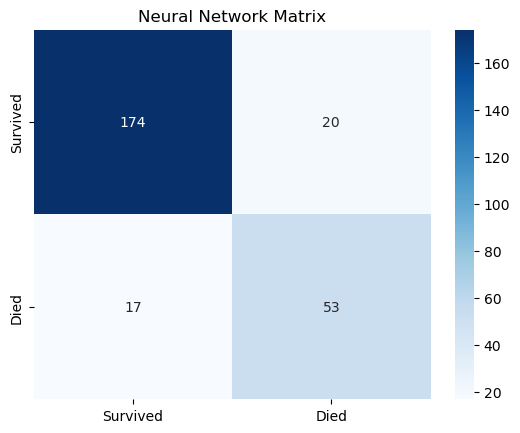

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data 
data = pd.read_csv('formatted_heart_failure_clinical_records.csv')

X = data.drop('death_event', axis=1)
y = data['death_event']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  Model Building
mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Evaluation
y_pred = mlp.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

# Visualising Results (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
plt.title('Neural Network Matrix')
plt.savefig('nn_matrix.png')